# Galaxy Redshift Prediction with VGG16


## 1. Setup

In [1]:
import os
import sys
import csv
import copy

project_root = os.path.abspath("../")
sys.path.insert(0, project_root)

import h5py
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from tqdm.notebook import tqdm

from src.data_loader import load_split, get_dataloaders, BAND_MEAN, BAND_STD
from src.metrics import redshift_metrics, evaluate_by_bin
from src.utils import (set_seed, get_device, SPLIT_COLORS,
                       plot_pred_vs_true, plot_binned_performance,
                       full_evaluation, full_evaluation_extended,
                       plot_learning_curves)
from src.models.vgg16 import VGG16Regressor

%load_ext autoreload
%autoreload 2

In [2]:
set_seed(42)
device = get_device()

Using MPS (Apple Metal GPU)


## 2. Data

In [19]:
BASE_DATA = os.path.abspath("../data/")
BASE_MODELS = os.path.abspath("../models/")
BASE_REPORTS = os.path.abspath("../reports/")
os.makedirs(BASE_MODELS, exist_ok=True)

TRAIN_PATH = os.path.join(BASE_DATA, "5x127x127_training_with_morphology.hdf5")
VAL_PATH = os.path.join(BASE_DATA, "5x127x127_validation_with_morphology.hdf5")
TEST_PATH = os.path.join(BASE_DATA, "5x127x127_testing_with_morphology.hdf5")

EXCLUDE = {"image", "specz_redshift", "specz_redshift_err", "specz_flag_homogeneous"}


In [4]:
df_train = load_split(TRAIN_PATH)
df_val = load_split(VAL_PATH)
df_test = load_split(TEST_PATH)

print(f"Train : {df_train.shape}")
print(f"Val   : {df_val.shape}")
print(f"Test  : {df_test.shape}")
print(f"Label range — min: {df_train['specz_redshift'].min():.4f}, "
      f"max: {df_train['specz_redshift'].max():.4f}, "
      f"mean: {df_train['specz_redshift'].mean():.4f}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples, 89 features
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples, 89 features
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples, 89 features
Train : (204573, 90)
Val   : (40914, 90)
Test  : (40914, 90)
Label range — min: 0.0101, max: 3.9979, mean: 0.5950


In [5]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    test_path=TEST_PATH,
    batch_size=32,
    num_workers=0,
)

imgs, labels = next(iter(train_loader))
print(f"images : {imgs.shape} | dtype: {imgs.dtype} | NaN: {imgs.isnan().any().item()}")
print(f"labels : min={labels.min():.3f}  max={labels.max():.3f}  mean={labels.mean():.3f}")
print(f"per-band mean: {imgs.mean(dim=[0, 2, 3]).numpy().round(3)}")
print(f"per-band std : {imgs.std(dim=[0, 2, 3]).numpy().round(3)}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples
images : torch.Size([32, 5, 127, 127]) | dtype: torch.float32 | NaN: False
labels : min=0.052  max=1.316  mean=0.366
per-band mean: [0.055 0.067 0.084 0.073 0.074]
per-band std : [0.795 0.979 1.305 1.178 1.108]


# 3. Model Architecture


In [6]:
SAVE_PATH = os.path.join(BASE_MODELS, "vgg16_full_best.pth")
RESUME_PATH = os.path.join(BASE_MODELS, "vgg16_full_latest.pth")
NUM_EPOCHS = 50
patience = 15

model_full = VGG16Regressor(in_channels=5, freeze_backbone=False).to(device)
criterion = nn.SmoothL1Loss(beta=0.1)

optimizer = optim.AdamW([
    {"params": model_full.features.parameters(), "lr": 1e-5},
    {"params": model_full.head.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=45, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])
scaler = torch.amp.GradScaler() if str(device) == "cuda" else None

print(f"Device          : {device}")
print(f"Total params    : {sum(p.numel() for p in model_full.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model_full.parameters() if p.requires_grad):,}")

Device          : mps
Total params    : 15,142,849
Trainable params: 15,142,849


## 3. VGG16 Training

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device, scaler=None, accum=2):
    model.train()
    total_loss = 0.0
    autocast_device = "cuda" if str(device) == "cuda" else "cpu"
    pbar = tqdm(loader, desc="Train", leave=True)
    optimizer.zero_grad(set_to_none=True)

    for i, (imgs, targets) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).squeeze()

        with torch.amp.autocast(autocast_device, enabled=(scaler is not None)):
            preds = model(imgs)
            loss = criterion(preds, targets) / accum

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (i + 1) % accum == 0:
            if scaler:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        batch_loss = loss.item() * accum
        total_loss += batch_loss
        gpu_gb = f"{torch.cuda.memory_allocated(device)/1e9:.1f}" if str(device) == "cuda" else "N/A"
        pbar.set_postfix({
            "batch_loss": f"{batch_loss:.4f}",
            "avg_loss" : f"{total_loss / (i + 1):.4f}",
            "best_val" : f"{best_loss:.4f}" if "best_loss" in globals() else "N/A",
            "lr" : f"{optimizer.param_groups[0]['lr']:.1e}",
            "GPU_GB" : gpu_gb,
        })

    if (i + 1) % accum != 0:
        if scaler:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).squeeze()
            preds = model(imgs)
            loss = criterion(preds, targets)
            total_loss += loss.item() * imgs.size(0)
            all_preds.append(preds.cpu().float().numpy())
            all_targets.append(targets.cpu().float().numpy())

    y_pred = np.concatenate(all_preds).flatten()
    y_true = np.concatenate(all_targets).flatten()
    metrics = redshift_metrics(y_pred, y_true)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics

In [8]:
start_epoch = 0
best_loss = float("inf")
no_improve = 0
train_losses = []
val_losses = []

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    model_full.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if "scaler_state_dict" in ckpt and scaler and ckpt["scaler_state_dict"]:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch = ckpt.get("epoch", 0) + 1
    best_loss = ckpt.get("best_val_loss", float("inf"))
    train_losses = ckpt.get("train_losses", [])
    val_losses = ckpt.get("val_losses", [])
    no_improve = ckpt.get("no_improve", 0)
    print(f"Resumed from epoch {start_epoch}, best val: {best_loss:.4f}, no_improve: {no_improve}")

checkpoint_template = {
    "model_params" : {"in_channels": 5, "backbone": "vgg16"},
    "batch_size" : 32,
    "criterion" : "SmoothL1Loss(beta=0.1)",
    "task" : "redshift_regression",
    "torch_version" : torch.__version__,
    "mean" : BAND_MEAN.tolist() if hasattr(BAND_MEAN, "tolist") else list(BAND_MEAN),
    "std" : BAND_STD.tolist() if hasattr(BAND_STD, "tolist") else list(BAND_STD),
    "optimizer_config": {
        "backbone_lr" : 1e-5,
        "head_lr" : 1e-3,
        "weight_decay" : 1e-4,
        "eta_min" : 1e-6,
        "T_max" : 45,
        "warmup_epochs": 5,
        "patience" : patience,
        "accum_steps" : 2,
    },
}

CSV_PATH = os.path.join(BASE_MODELS, "vgg16_training_metrics.csv")
if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        csv.writer(f).writerow([
            "epoch", "train_loss", "val_loss", "val_mae", "val_rmse",
            "val_r2", "val_nmad", "val_outlier_pct",
            "within_0.1z", "within_0.05z", "val_bias",
            "gap", "best_val_loss", "no_improve", "is_best", "lr"
        ])

print(f"Training from epoch {start_epoch}/{NUM_EPOCHS}")

Resumed from epoch 50, best val: 0.0339, no_improve: 0
Training from epoch 50/50


In [9]:
for epoch in range(start_epoch, NUM_EPOCHS):

    tr_loss = train_epoch(model_full, train_loader, optimizer, criterion, device, scaler)
    val_metrics = evaluate(model_full, val_loader, criterion, device)
    val_loss = val_metrics["loss"]
    current_lr = optimizer.param_groups[0]["lr"]
    gap = tr_loss - val_loss

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    scheduler.step()

    is_best = val_loss < best_loss * 0.999

    latest = copy.deepcopy(checkpoint_template)
    latest.update({
        "model_state_dict" : model_full.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch" : epoch,
        "best_val_loss" : best_loss,
        "no_improve" : no_improve,
        "train_losses" : train_losses.copy(),
        "val_losses" : val_losses.copy(),
        **({"scaler_state_dict": scaler.state_dict()} if scaler else {}),
    })
    torch.save(latest, RESUME_PATH)

    with open(CSV_PATH, "a", newline="") as f:
        csv.writer(f).writerow([
            epoch + 1,
            round(tr_loss, 6), round(val_loss, 6),
            round(val_metrics["mae"], 6), round(val_metrics["rmse"], 6),
            round(val_metrics["r2"], 6), round(val_metrics["nmad"], 6),
            round(val_metrics["outlier_pct"], 4),
            round(val_metrics["within_0.1z"], 4), round(val_metrics["within_0.05z"], 4),
            round(val_metrics["bias"], 6),
            round(gap, 6), round(best_loss, 6),
            no_improve, is_best, current_lr
        ])

    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses, "b-", label="Train")
    ax1.plot(val_losses, "r-", label="Val")
    ax1.set_yscale("log")
    ax1.set_title(f"Epoch {epoch+1} | Best: {best_loss:.4f}")
    ax1.legend()
    ax1.grid()

    metrics_text = [
        ("MAE", f"{val_metrics['mae']:.4f}"),
        ("RMSE", f"{val_metrics['rmse']:.4f}"),
        ("R2", f"{val_metrics['r2']:.4f}"),
        ("NMAD", f"{val_metrics['nmad']:.4f}"),
        ("Outlier%", f"{val_metrics['outlier_pct']:.2f}%"),
        ("Within 0.1z", f"{val_metrics['within_0.1z']*100:.1f}%"),
        ("Within 0.05z", f"{val_metrics['within_0.05z']*100:.1f}%"),
        ("No improve", f"{no_improve} / {patience}"),
        ("LR", f"{current_lr:.2e}"),
    ]
    for i, (label, value) in enumerate(metrics_text):
        ax2.text(0.1, 0.9 - i * 0.1, f"{label:<14} {value}", fontsize=12, transform=ax2.transAxes)
    ax2.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1} | Train {tr_loss:.4f} | Val {val_loss:.4f} | "
          f"Gap {gap:+.4f} | MAE {val_metrics['mae']:.4f} | NMAD {val_metrics['nmad']:.4f} | "
          f"Outlier% {val_metrics['outlier_pct']:.2f} | R2 {val_metrics['r2']:.4f} | LR {current_lr:.2e}")

    if is_best:
        best_loss = val_loss
        no_improve = 0
        ckpt = copy.deepcopy(checkpoint_template)
        ckpt.update({
            "model_state_dict" : model_full.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch" : epoch,
            "best_val_loss" : best_loss,
            "no_improve" : 0,
            "train_losses" : train_losses.copy(),
            "val_losses" : val_losses.copy(),
            "val_metrics" : val_metrics,
            **({"scaler_state_dict": scaler.state_dict()} if scaler else {}),
        })
        torch.save(ckpt, SAVE_PATH)
        print(f"  → New best: {best_loss:.4f}")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 5 == 0:
        torch.save(
            model_full.state_dict(),
            os.path.join(BASE_MODELS, f"vgg16_epoch_{epoch+1:02d}.pth")
        )

print(f"Training complete. Best val loss: {best_loss:.4f}")

Training complete. Best val loss: 0.0339


# 4. Evaluation

In [10]:
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model_full.load_state_dict(ckpt["model_state_dict"])
model_full.eval()
print(f"Loaded best model from epoch {ckpt['epoch']+1} (val loss: {ckpt['best_val_loss']:.4f})")

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, targets in tqdm(test_loader, desc="Test inference"):
        preds = model_full(imgs.to(device))
        all_preds.append(preds.cpu().float().numpy())
        all_targets.append(targets.numpy())

y_pred = np.concatenate(all_preds).flatten()
y_true = np.concatenate(all_targets).flatten()

# Primary range: 0.0 ≤ z ≤ 2.5
mask_primary = (y_true >= 0.0) & (y_true <= 2.5)
y_pred_primary = y_pred[mask_primary]
y_true_primary = y_true[mask_primary]

print(f"\n=== Primary range (0.0 ≤ z ≤ 2.5) — N={mask_primary.sum():,} ===")
test_metrics = redshift_metrics(y_pred_primary, y_true_primary)
for key, value in test_metrics.items():
    print(f"  {key:<28}: {value:.4f}")

evaluate_by_bin(y_true_primary, y_pred_primary,
                bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

Loaded best model from epoch 49 (val loss: 0.0339)


Test inference:   0%|          | 0/1279 [00:00<?, ?it/s]


=== Primary range (0.0 ≤ z ≤ 2.5) — N=40,039 ===
  rmse                        : 0.1561
  mae                         : 0.0457
  bias                        : 0.0011
  r2                          : 0.8790
  nmad                        : 0.0166
  outlier_pct                 : 2.2803
  cat_outlier_pct             : 1.1938
  three_sigma_outlier_pct     : 7.5851
  outlier_abs_pct             : 0.7717
  lsst_cat_outlier_pct        : 0.7717
  within_0.1z                 : 0.9675
  within_0.05z                : 0.9244

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.0915   0.0139      0.94%       0.19%   0.0019
0.5–1.0       14,815   0.1506   0.0163      1.97%       0.84%  -0.0008
1.0–1.5        2,069   0.3466   0.0402      8.89%       4.01%   0.0016
1.5–2.0          938   0.3326   0.0540     13.65%       2.77%   0.0000
2.0–2.5        1,047   0.3089   0.0267      7.64%       2

,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.091461,0.013938,0.942350,0.194013,0.001916
1,0.5–1.0,14815,0.150580,0.016272,1.970975,0.836990,-0.000843
2,1.0–1.5,2069,0.346586,0.040245,8.893185,4.011600,0.001604
3,1.5–2.0,938,0.332553,0.054047,13.646055,2.771855,0.000012
4,2.0–2.5,1047,0.308911,0.026692,7.640879,2.960840,0.004881


In [23]:
np.save(os.path.join(BASE_MODELS, "vgg16_ypred.npy"), y_pred_primary)
np.save(os.path.join(BASE_MODELS, "vgg16_ytrue.npy"), y_true_primary)

# 5. Visualizations

Scatter plot saved → /Users/arpinejanunts/Desktop/Capstone/reports/vgg16_scatter.png


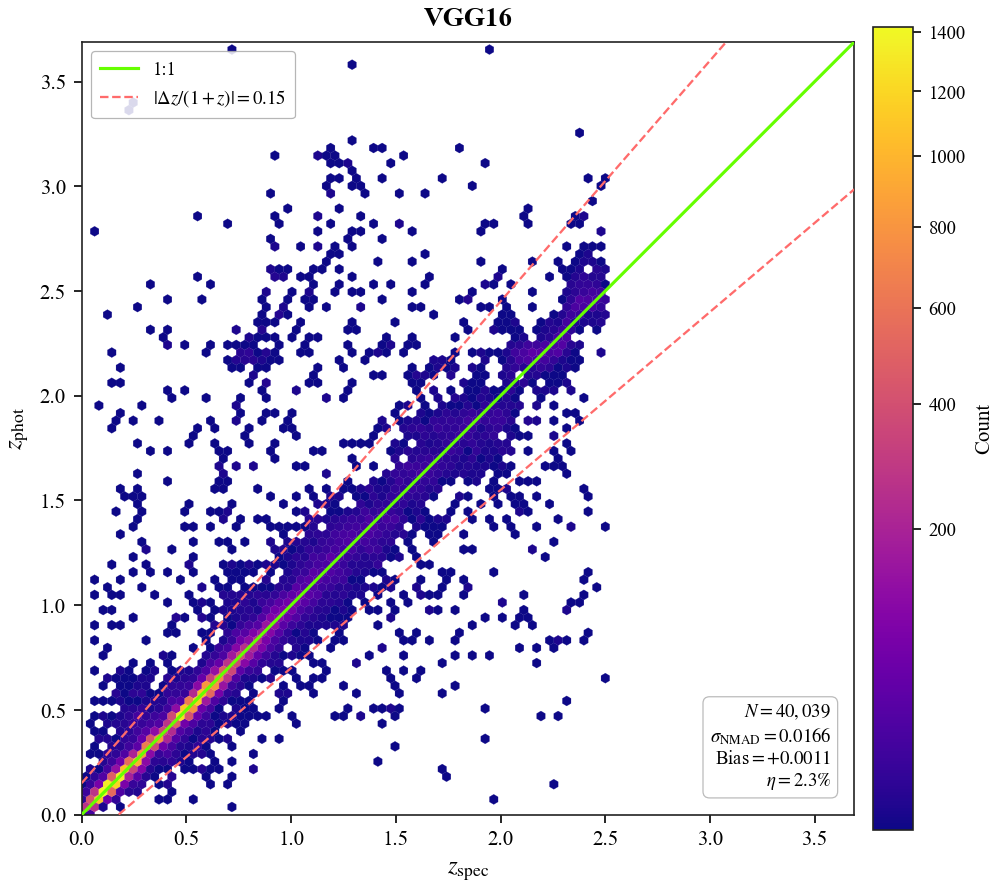

In [24]:
plot_pred_vs_true(
    y_true_primary,
    y_pred_primary,
    name="VGG16",
    save_path=os.path.join(BASE_REPORTS, "vgg16_scatter.png"),
)

Binned performance saved → /Users/arpinejanunts/Desktop/Capstone/reports/vgg16_binned.png


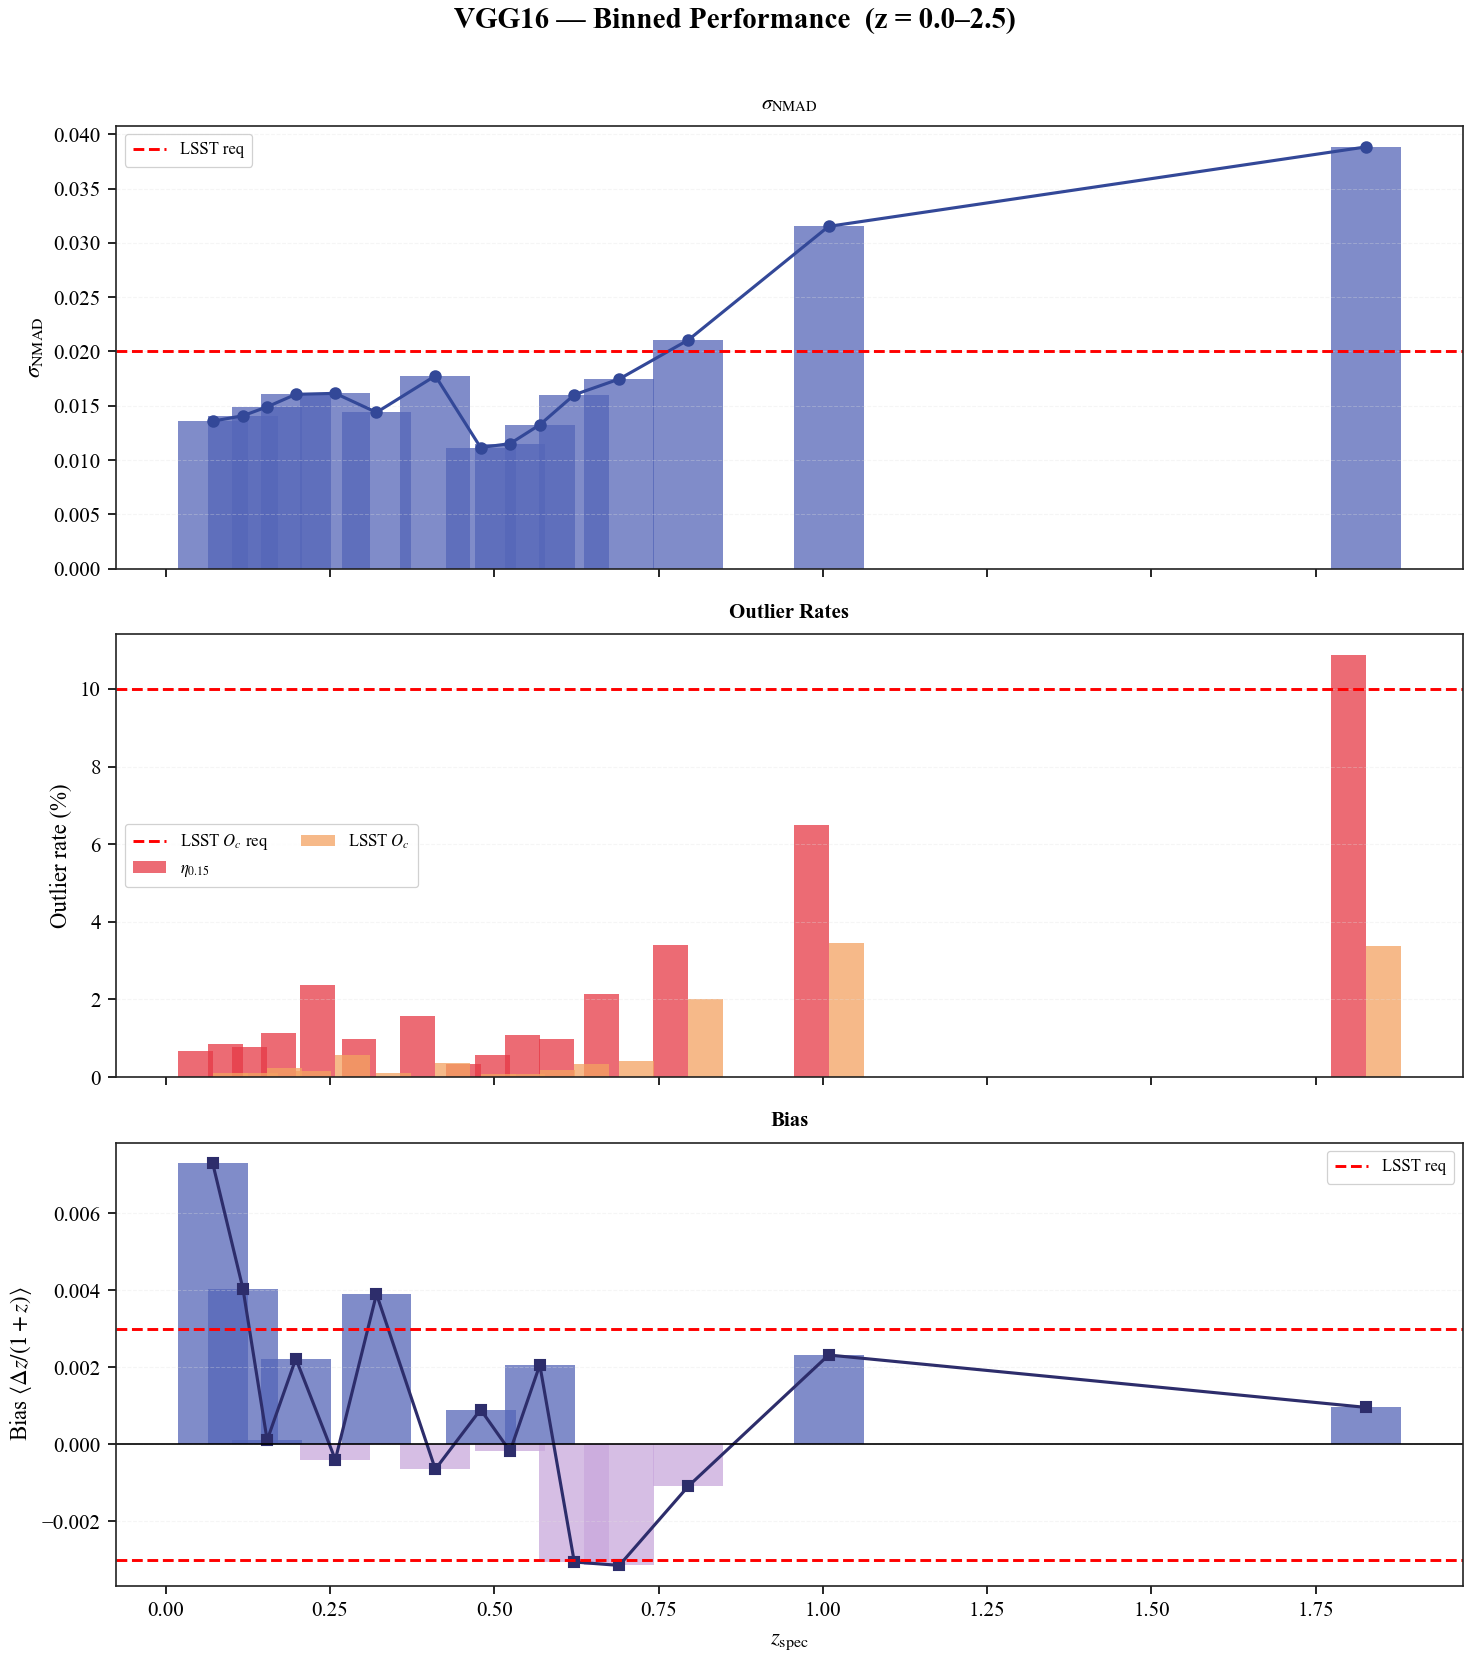

In [25]:
plot_binned_performance(
    y_true_primary,
    y_pred_primary,
    name="VGG16",
    n_bins=15,
    z_range=(0.0, 2.5),
    save_path=os.path.join(BASE_REPORTS, "vgg16_binned.png"),
)

Figure saved → /Users/arpinejanunts/Desktop/Capstone/reports/vgg16_full_eval.png


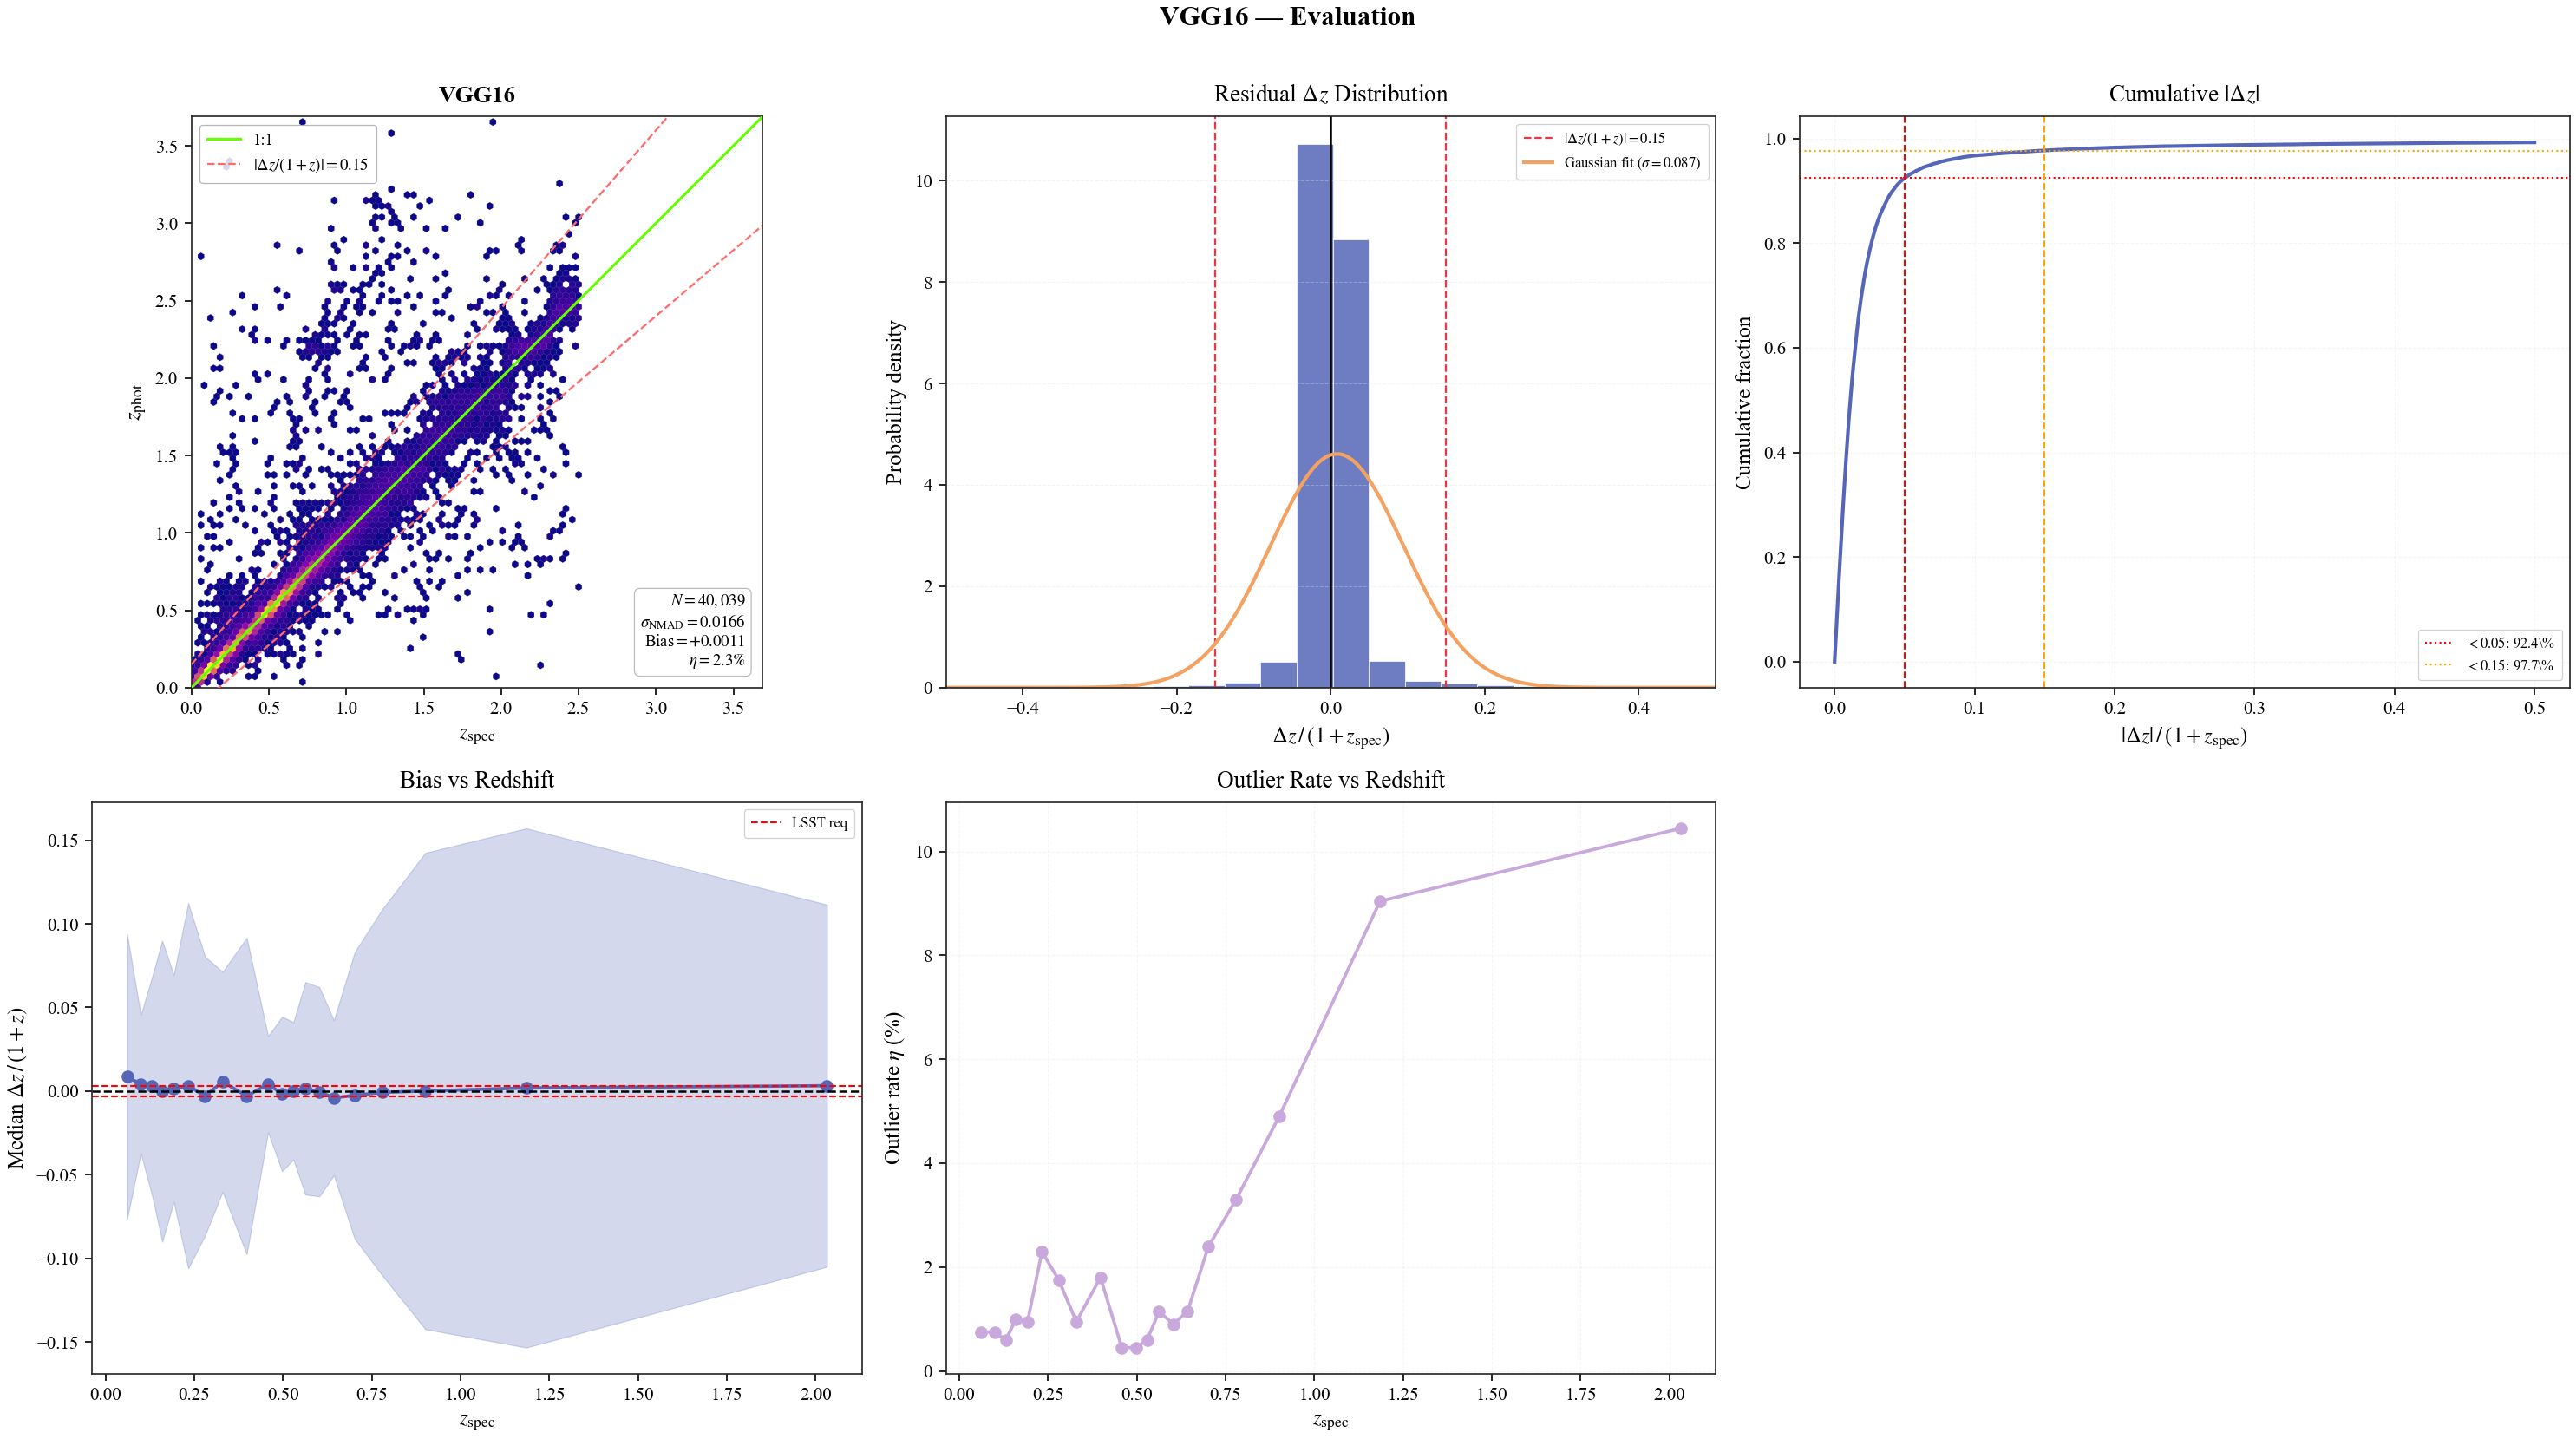

In [26]:
full_evaluation(
    name="VGG16",
    y_true=y_true_primary,
    y_pred=y_pred_primary,
    save_path=os.path.join(BASE_REPORTS, "vgg16_full_eval.png"),
)